# Root Cause Analysis: Latency and Reward Outliers

This notebook diagnoses extremely high `ambulance_latency_s` and very negative `reward_total` values in DQN evaluation logs. It is diagnosis-only: it does not modify the environment, reward function, training code, evaluation code, or configuration.

## 1. Load data

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
DIAGNOSTICS_DIR = RESULTS_DIR / "diagnostics"
DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)

TOTAL_PRB = 100
LATENCY_ERROR_TOL = 1e-6

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.size": 11,
    }
)

def latest_file(pattern, required=True):
    matches = sorted(RESULTS_DIR.glob(pattern), key=lambda path: path.stat().st_mtime, reverse=True)
    if not matches:
        if required:
            raise FileNotFoundError(f"No files found for {RESULTS_DIR / pattern}")
        return None
    return matches[0]

debug_steps_path = latest_file("dqn_300k_debug_steps_*.csv", required=False)
if debug_steps_path is not None:
    steps_path = debug_steps_path
    summary_path = latest_file("dqn_300k_debug_summary_*.csv", required=False)
    log_source = "debug"
else:
    steps_path = latest_file("dqn_300k_steps_*.csv")
    summary_path = latest_file("dqn_300k_summary_*.csv", required=False)
    log_source = "standard"

steps_df = pd.read_csv(steps_path)
summary_df = pd.read_csv(summary_path) if summary_path is not None else None

print(f"Using {log_source} step-level log: {steps_path}")
if summary_path is not None:
    print(f"Loaded episode summary: {summary_path}")
else:
    print("No matching summary CSV found; continuing with step-level logs only.")
print(f"Step rows: {len(steps_df)}")
print(f"Columns: {list(steps_df.columns)}")

Using debug step-level log: D:\Projects\dqn-ran-slicing-oran-iov\results\dqn_300k_debug_steps_20260609_065925.csv
Loaded episode summary: D:\Projects\dqn-ran-slicing-oran-iov\results\dqn_300k_debug_summary_20260609_065925.csv
Step rows: 6000
Columns: ['episode', 'step', 'action', 'alpha_A', 'prb_ambulance', 'prb_ordinary', 'ambulance_arrival_mbit', 'ordinary_arrival_mbit', 'ambulance_capacity_mbps', 'ordinary_capacity_mbps', 'ambulance_queue_mbit', 'ordinary_queue_mbit', 'ambulance_latency_s', 'ambulance_sla_violation', 'ordinary_throughput_mbps', 'prb_utilization', 'reward_total', 'n_ambulance', 'n_ordinary_vehicles', 'n_embb_users', 'ambulance_emergency', 'embb_surge_active', 'ambulance_queue_before_mbit', 'ordinary_queue_before_mbit', 'latency_numerator_mbit', 'latency_denominator_mbps', 'ambulance_queue_after_mbit', 'ordinary_queue_after_mbit', 'reconstructed_latency_s', 'latency_excess_raw', 'sla_violation_indicator', 'ordinary_throughput_reward', 'resource_waste_penalty', 'action

In [ ]:
def parse_boolean_series(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.strip().str.lower().isin(["true", "1", "yes"])

numeric_columns = [
    "episode", "step", "action", "alpha_A", "prb_ambulance", "prb_ordinary",
    "n_ambulance", "ambulance_arrival_mbit", "ambulance_capacity_mbps",
    "ambulance_queue_mbit", "ambulance_queue_before_mbit", "ambulance_queue_after_mbit",
    "latency_numerator_mbit", "latency_denominator_mbps", "reconstructed_latency_s",
    "ambulance_latency_s", "ambulance_sla_violation", "ordinary_throughput_mbps",
    "prb_utilization", "reward_total",
]
for column in numeric_columns:
    if column in steps_df.columns:
        steps_df[column] = pd.to_numeric(steps_df[column], errors="coerce")

if "ambulance_emergency" in steps_df.columns:
    steps_df["ambulance_emergency_bool"] = parse_boolean_series(steps_df["ambulance_emergency"])
else:
    steps_df["ambulance_emergency_bool"] = False

required_base_columns = [
    "episode", "step", "action", "alpha_A", "n_ambulance", "ambulance_arrival_mbit",
    "ambulance_capacity_mbps", "ambulance_latency_s", "ambulance_sla_violation",
    "ordinary_throughput_mbps", "prb_utilization", "reward_total",
]
missing_base = [column for column in required_base_columns if column not in steps_df.columns]
if missing_base:
    raise KeyError(f"Missing required base columns: {missing_base}. Available columns: {list(steps_df.columns)}")

required_debug_columns = [
    "ambulance_queue_before_mbit", "ambulance_queue_after_mbit",
    "latency_numerator_mbit", "latency_denominator_mbps", "reconstructed_latency_s",
]
missing_debug_columns = [column for column in required_debug_columns if column not in steps_df.columns]
if missing_debug_columns:
    print(f"Missing debug columns: {missing_debug_columns}")
else:
    print("All required debug columns are present.")

display(steps_df.head())

All required debug columns are present.


,episode,step,action,alpha_A,prb_ambulance,prb_ordinary,ambulance_arrival_mbit,ordinary_arrival_mbit,ambulance_capacity_mbps,ordinary_capacity_mbps,...,sla_violation_indicator,ordinary_throughput_reward,resource_waste_penalty,action_change_penalty,reward_latency_excess,reward_sla_violation,reward_ordinary_throughput,reward_resource_waste,reward_action_change,ambulance_emergency_bool
0,0,0,2,0.3,30,70,0.0,7.92,0.0,16.456650,...,0,0.9900,0.0,0.0,0.0,0,0.9900,0.0,0.0,False
1,0,1,2,0.3,30,70,0.0,7.38,0.0,16.596642,...,0,0.9225,0.0,0.0,0.0,0,0.9225,0.0,0.0,False
2,0,2,2,0.3,30,70,0.0,10.20,0.0,15.519641,...,0,1.0000,0.0,0.0,0.0,0,1.0000,0.0,0.0,False
3,0,3,2,0.3,30,70,0.0,8.64,0.0,16.819433,...,0,1.0000,0.0,0.0,0.0,0,1.0000,0.0,0.0,False
4,0,4,2,0.3,30,70,0.0,6.88,0.0,16.743460,...,0,0.8600,0.0,0.0,0.0,0,0.8600,0.0,0.0,False


## 2. Basic statistics

In [ ]:
queue_for_latency_column = "ambulance_queue_before_mbit" if "ambulance_queue_before_mbit" in steps_df.columns else "ambulance_queue_mbit"
metrics = [
    "reward_total", "ambulance_latency_s", "ambulance_arrival_mbit",
    "ambulance_capacity_mbps", queue_for_latency_column, "ordinary_throughput_mbps",
    "alpha_A", "n_ambulance",
]
metrics = [column for column in metrics if column in steps_df.columns]

print(f"Number of rows: {len(steps_df)}")
print(f"Number of episodes: {steps_df['episode'].nunique()}")
display(steps_df[metrics].agg(["min", "max", "mean", "median"]).T)

percentile_stats = pd.DataFrame(
    {
        "1st_percentile": steps_df[["reward_total", "ambulance_latency_s"]].quantile(0.01),
        "5th_percentile": steps_df[["reward_total", "ambulance_latency_s"]].quantile(0.05),
        "95th_percentile": steps_df[["reward_total", "ambulance_latency_s"]].quantile(0.95),
        "99th_percentile": steps_df[["reward_total", "ambulance_latency_s"]].quantile(0.99),
    }
)
display(percentile_stats)

Number of rows: 6000
Number of episodes: 30


,min,max,mean,median
reward_total,-31.497994,1.000000,0.285875,1.000000
ambulance_latency_s,0.000000,0.839433,0.024546,0.005120
ambulance_arrival_mbit,0.000000,1.810000,0.314973,0.040000
ambulance_capacity_mbps,0.000000,38.554806,6.848757,5.238386
ambulance_queue_before_mbit,0.000000,0.000000,0.000000,0.000000
ordinary_throughput_mbps,2.380000,22.941198,10.400896,9.424548
alpha_A,0.100000,0.800000,0.405600,0.300000
n_ambulance,0.000000,3.000000,0.914833,1.000000


,1st_percentile,5th_percentile,95th_percentile,99th_percentile
reward_total,-11.157105,-9.103278,1.000000,1.000000
ambulance_latency_s,0.000000,0.000000,0.101224,0.169583


## 3. Identify worst latency and worst reward steps

In [ ]:
inspection_columns = [
    "episode", "step", "action", "alpha_A", "prb_ambulance", "prb_ordinary",
    "n_ambulance", "ambulance_emergency", "ambulance_arrival_mbit",
    "ambulance_capacity_mbps", "ambulance_queue_before_mbit", "ambulance_queue_after_mbit",
    "latency_numerator_mbit", "latency_denominator_mbps", "reconstructed_latency_s",
    "ambulance_latency_s", "ambulance_sla_violation", "ordinary_throughput_mbps",
    "prb_utilization", "reward_total",
]
available_inspection_columns = [column for column in inspection_columns if column in steps_df.columns]

print("Top 30 lowest reward_total steps")
worst_reward_steps = steps_df.nsmallest(30, "reward_total")[available_inspection_columns]
display(worst_reward_steps)

print("Top 30 highest ambulance_latency_s steps")
worst_latency_steps = steps_df.nlargest(30, "ambulance_latency_s")[available_inspection_columns]
display(worst_latency_steps)

Top 30 lowest reward_total steps


,episode,step,action,alpha_A,prb_ambulance,prb_ordinary,n_ambulance,ambulance_emergency,ambulance_arrival_mbit,ambulance_capacity_mbps,ambulance_queue_before_mbit,ambulance_queue_after_mbit,latency_numerator_mbit,latency_denominator_mbps,reconstructed_latency_s,ambulance_latency_s,ambulance_sla_violation,ordinary_throughput_mbps,prb_utilization,reward_total
278,1,78,0,0.1,10,90,3,True,1.42,1.691617,0.0,0.0,1.42,1.691618,0.839433,0.839433,1,5.480000,0.311458,-31.497994
597,2,197,0,0.1,10,90,3,True,1.50,2.140813,0.0,0.0,1.50,2.140814,0.700668,0.700668,1,4.380000,0.251303,-27.472538
5616,28,16,0,0.1,10,90,3,True,1.55,2.750688,0.0,0.0,1.55,2.750689,0.563495,0.563495,1,4.700000,0.259498,-23.357356
5661,28,61,0,0.1,10,90,2,True,1.06,2.423702,0.0,0.0,1.06,2.423703,0.437347,0.437347,1,6.360000,0.308667,-19.365417
1855,9,55,2,0.3,30,70,3,True,1.52,3.894933,0.0,0.0,1.52,3.894934,0.390251,0.390251,1,7.800000,0.429833,-17.732517
3755,18,155,2,0.3,30,70,3,True,1.50,4.323300,0.0,0.0,1.50,4.323301,0.346957,0.346957,1,16.229916,0.804086,-16.408712
2142,10,142,2,0.3,30,70,3,True,1.43,5.199868,0.0,0.0,1.43,5.199869,0.275007,0.275007,1,4.640000,0.279103,-14.710208
3728,18,128,2,0.3,30,70,3,True,1.61,5.663419,0.0,0.0,1.61,5.663420,0.284281,0.284281,1,16.569496,0.785284,-14.528416
5348,26,148,2,0.3,30,70,3,True,1.59,5.694161,0.0,0.0,1.59,5.694162,0.279233,0.279233,1,16.565975,0.783770,-14.377001
2879,14,79,2,0.3,30,70,3,True,1.69,6.166831,0.0,0.0,1.69,6.166832,0.274047,0.274047,1,13.820000,0.661510,-14.221402


Top 30 highest ambulance_latency_s steps


,episode,step,action,alpha_A,prb_ambulance,prb_ordinary,n_ambulance,ambulance_emergency,ambulance_arrival_mbit,ambulance_capacity_mbps,ambulance_queue_before_mbit,ambulance_queue_after_mbit,latency_numerator_mbit,latency_denominator_mbps,reconstructed_latency_s,ambulance_latency_s,ambulance_sla_violation,ordinary_throughput_mbps,prb_utilization,reward_total
278,1,78,0,0.1,10,90,3,True,1.42,1.691617,0.0,0.0,1.42,1.691618,0.839433,0.839433,1,5.480000,0.311458,-31.497994
597,2,197,0,0.1,10,90,3,True,1.50,2.140813,0.0,0.0,1.50,2.140814,0.700668,0.700668,1,4.380000,0.251303,-27.472538
5616,28,16,0,0.1,10,90,3,True,1.55,2.750688,0.0,0.0,1.55,2.750689,0.563495,0.563495,1,4.700000,0.259498,-23.357356
5661,28,61,0,0.1,10,90,2,True,1.06,2.423702,0.0,0.0,1.06,2.423703,0.437347,0.437347,1,6.360000,0.308667,-19.365417
1855,9,55,2,0.3,30,70,3,True,1.52,3.894933,0.0,0.0,1.52,3.894934,0.390251,0.390251,1,7.800000,0.429833,-17.732517
3755,18,155,2,0.3,30,70,3,True,1.50,4.323300,0.0,0.0,1.50,4.323301,0.346957,0.346957,1,16.229916,0.804086,-16.408712
3728,18,128,2,0.3,30,70,3,True,1.61,5.663419,0.0,0.0,1.61,5.663420,0.284281,0.284281,1,16.569496,0.785284,-14.528416
5348,26,148,2,0.3,30,70,3,True,1.59,5.694161,0.0,0.0,1.59,5.694162,0.279233,0.279233,1,16.565975,0.783770,-14.377001
2142,10,142,2,0.3,30,70,3,True,1.43,5.199868,0.0,0.0,1.43,5.199869,0.275007,0.275007,1,4.640000,0.279103,-14.710208
2879,14,79,2,0.3,30,70,3,True,1.69,6.166831,0.0,0.0,1.69,6.166832,0.274047,0.274047,1,13.820000,0.661510,-14.221402


## 4. Analyze whether latency outliers are caused by capacity, arrival, queue, or action

In [ ]:
steps_df["latency_ms"] = steps_df["ambulance_latency_s"] * 1000.0

if not missing_debug_columns:
    steps_df["recomputed_latency"] = steps_df["latency_numerator_mbit"] / steps_df["latency_denominator_mbps"]
    steps_df["latency_error"] = (steps_df["recomputed_latency"] - steps_df["ambulance_latency_s"]).abs()
else:
    steps_df["recomputed_latency"] = np.nan
    steps_df["latency_error"] = np.nan

numerator_col = "latency_numerator_mbit" if "latency_numerator_mbit" in steps_df.columns else "ambulance_arrival_mbit"
denominator_col = "latency_denominator_mbps" if "latency_denominator_mbps" in steps_df.columns else "ambulance_capacity_mbps"
queue_before_col = "ambulance_queue_before_mbit" if "ambulance_queue_before_mbit" in steps_df.columns else "ambulance_queue_mbit"

steps_df["high_latency_numerator_mbit"] = steps_df[numerator_col] > steps_df[numerator_col].quantile(0.95)
steps_df["low_latency_denominator_mbps"] = steps_df[denominator_col] < steps_df[denominator_col].quantile(0.05)
steps_df["high_queue_before_mbit"] = steps_df[queue_before_col] > steps_df[queue_before_col].quantile(0.95)
steps_df["high_arrival"] = steps_df["ambulance_arrival_mbit"] > steps_df["ambulance_arrival_mbit"].quantile(0.95)
steps_df["low_alpha"] = steps_df["alpha_A"] <= 0.3
steps_df["emergency_and_low_alpha"] = steps_df["ambulance_emergency_bool"] & steps_df["low_alpha"]
steps_df["estimated_service_margin"] = steps_df[denominator_col] - steps_df["ambulance_arrival_mbit"]

print("Strict latency reconstruction check")
if missing_debug_columns:
    print(f"Cannot reconstruct latency because debug columns are missing: {missing_debug_columns}")
else:
    print(f"max latency_error: {steps_df['latency_error'].max()}")
    print(f"latency_error < {LATENCY_ERROR_TOL}: {steps_df['latency_error'].max() < LATENCY_ERROR_TOL}")

display(
    steps_df[
        [
            "latency_ms", "recomputed_latency", "latency_error",
            "high_latency_numerator_mbit", "low_latency_denominator_mbps",
            "high_queue_before_mbit", "high_arrival", "low_alpha",
            "emergency_and_low_alpha", "estimated_service_margin",
        ]
    ].describe(include="all")
)

Strict latency reconstruction check
max latency_error: 1.1102230246251565e-16
latency_error < 1e-06: True


,latency_ms,recomputed_latency,latency_error,high_latency_numerator_mbit,low_latency_denominator_mbps,high_queue_before_mbit,high_arrival,low_alpha,emergency_and_low_alpha,estimated_service_margin
count,6000.000000,6000.000000,6.000000e+03,6000,6000,6000,6000,6000,6000,6000.000000
unique,NaN,NaN,NaN,2,1,1,2,2,2,NaN
top,NaN,NaN,NaN,False,False,False,False,False,False,NaN
freq,NaN,NaN,NaN,5701,6000,6000,5701,5788,5996,NaN
mean,24.545544,0.024546,2.786188e-17,NaN,NaN,NaN,NaN,NaN,NaN,6.533784
std,42.280826,0.042281,3.215660e-17,NaN,NaN,NaN,NaN,NaN,NaN,7.200188
min,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,0.000001
25%,0.000000,0.000000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,0.000001
50%,5.120228,0.005120,1.387779e-17,NaN,NaN,NaN,NaN,NaN,NaN,5.079566
75%,35.746880,0.035747,5.551115e-17,NaN,NaN,NaN,NaN,NaN,NaN,11.301814


## 5. Analyze emergency vs non-emergency behavior

In [ ]:
group_metrics = dict(
    count=("reward_total", "size"),
    mean_reward_total=("reward_total", "mean"),
    mean_ambulance_latency_s=("ambulance_latency_s", "mean"),
    max_ambulance_latency_s=("ambulance_latency_s", "max"),
    mean_latency_numerator_mbit=(numerator_col, "mean"),
    mean_latency_denominator_mbps=(denominator_col, "mean"),
    mean_ambulance_arrival_mbit=("ambulance_arrival_mbit", "mean"),
    mean_ambulance_queue_before_mbit=(queue_before_col, "mean"),
    mean_ambulance_sla_violation=("ambulance_sla_violation", "mean"),
)

print("Grouped by action")
display(steps_df.groupby("action").agg(**group_metrics).reset_index())

print("Grouped by ambulance_emergency")
display(steps_df.groupby("ambulance_emergency_bool").agg(**group_metrics).reset_index())

print("Grouped by emergency_and_low_alpha")
display(steps_df.groupby("emergency_and_low_alpha").agg(**group_metrics).reset_index())

Grouped by action


,action,count,mean_reward_total,mean_ambulance_latency_s,max_ambulance_latency_s,mean_latency_numerator_mbit,mean_latency_denominator_mbps,mean_ambulance_arrival_mbit,mean_ambulance_queue_before_mbit,mean_ambulance_sla_violation
0,0,212,0.167555,0.025969,0.839433,0.056792,1.596762,0.056792,0.0,0.018868
1,2,4025,0.670771,0.008187,0.390251,0.053058,3.278885,0.053058,0.0,0.021366
2,4,63,0.891153,0.005747,0.059106,0.054286,7.490619,0.054286,0.0,0.000000
3,5,723,-0.050694,0.057984,0.220992,0.732393,13.681211,0.732393,0.0,0.095436
4,6,420,-1.026750,0.065389,0.205752,1.015286,16.431857,1.015286,0.0,0.173810
5,7,557,-1.092250,0.070143,0.203618,1.265494,18.477047,1.265494,0.0,0.154399


Grouped by ambulance_emergency


,ambulance_emergency_bool,count,mean_reward_total,mean_ambulance_latency_s,max_ambulance_latency_s,mean_latency_numerator_mbit,mean_latency_denominator_mbps,mean_ambulance_arrival_mbit,mean_ambulance_queue_before_mbit,mean_ambulance_sla_violation
0,False,4288,0.909780,0.004164,0.085750,0.022267,3.238618,0.022267,0.0,0.000000
1,True,1712,-1.276805,0.075594,0.839433,1.048107,15.890976,1.048107,0.0,0.185748


Grouped by emergency_and_low_alpha


,emergency_and_low_alpha,count,mean_reward_total,mean_ambulance_latency_s,max_ambulance_latency_s,mean_latency_numerator_mbit,mean_latency_denominator_mbps,mean_ambulance_arrival_mbit,mean_ambulance_queue_before_mbit,mean_ambulance_sla_violation
0,False,5996,0.303025,0.024138,0.390251,0.314261,6.851824,0.314261,0.0,0.052368
1,True,4,-25.423326,0.635236,0.839433,1.382500,2.251706,1.382500,0.0,1.000000


## 6. Analyze action choices during high-latency steps

In [ ]:
top_latency = steps_df.nlargest(30, "ambulance_latency_s").copy()
root_conditions = [
    "high_latency_numerator_mbit", "low_latency_denominator_mbps",
    "high_queue_before_mbit", "high_arrival", "emergency_and_low_alpha",
]
root_cause_table = pd.DataFrame(
    [
        {
            "condition": condition,
            "count_in_top_30_latency": int(top_latency[condition].sum()),
            "percent_in_top_30_latency": 100.0 * float(top_latency[condition].mean()),
        }
        for condition in root_conditions
    ]
).sort_values("count_in_top_30_latency", ascending=False)
display(root_cause_table)

high_latency_threshold = steps_df["ambulance_latency_s"].quantile(0.95)
high_latency_df = steps_df[steps_df["ambulance_latency_s"] >= high_latency_threshold]
print(f"High-latency threshold, 95th percentile: {high_latency_threshold}")
print(f"High-latency rows: {len(high_latency_df)}")
display(
    high_latency_df.groupby("action")
    .agg(
        count=("reward_total", "size"),
        mean_alpha_A=("alpha_A", "mean"),
        mean_reward_total=("reward_total", "mean"),
        mean_latency_s=("ambulance_latency_s", "mean"),
        mean_numerator_mbit=(numerator_col, "mean"),
        mean_denominator_mbps=(denominator_col, "mean"),
        mean_queue_before_mbit=(queue_before_col, "mean"),
        emergency_rate=("ambulance_emergency_bool", "mean"),
    )
    .reset_index()
)

,condition,count_in_top_30_latency,percent_in_top_30_latency
0,high_latency_numerator_mbit,14,46.666667
3,high_arrival,14,46.666667
4,emergency_and_low_alpha,4,13.333333
2,high_queue_before_mbit,0,0.000000
1,low_latency_denominator_mbps,0,0.000000


High-latency threshold, 95th percentile: 0.10122376627109418
High-latency rows: 300


,action,count,mean_alpha_A,mean_reward_total,mean_latency_s,mean_numerator_mbit,mean_denominator_mbps,mean_queue_before_mbit,emergency_rate
0,0,4,0.1,-25.423326,0.635236,1.382500,2.251706,0.0,1.0
1,2,86,0.3,-11.576380,0.183828,1.242791,7.029852,0.0,1.0
2,5,64,0.6,-9.724558,0.123580,0.940312,7.839332,0.0,1.0
3,6,67,0.7,-9.813023,0.122301,1.441493,12.077878,0.0,1.0
4,7,79,0.8,-10.101932,0.122789,1.530127,12.740027,0.0,1.0


## Consistency checks

In [ ]:
consistency_checks = {}
consistency_checks["arrival_positive_with_zero_ambulance"] = steps_df[
    (steps_df["ambulance_arrival_mbit"] > 0) & (steps_df["n_ambulance"] == 0)
]
consistency_checks["ambulance_positive_with_zero_capacity"] = steps_df[
    (steps_df["n_ambulance"] > 0) & (steps_df["ambulance_capacity_mbps"] == 0)
]
consistency_checks["emergency_with_zero_ambulance"] = steps_df[
    steps_df["ambulance_emergency_bool"] & (steps_df["n_ambulance"] == 0)
]
consistency_checks["alpha_outside_valid_range"] = steps_df[
    (steps_df["alpha_A"] < 0.1) | (steps_df["alpha_A"] > 0.8)
]
if "prb_ambulance" in steps_df.columns and "prb_ordinary" in steps_df.columns:
    consistency_checks["prb_sum_not_total"] = steps_df[
        (steps_df["prb_ambulance"] + steps_df["prb_ordinary"]) != TOTAL_PRB
    ]

very_high_latency_threshold = steps_df["ambulance_latency_s"].quantile(0.99)
consistency_checks["high_latency_unexplained_by_numerator_denominator"] = steps_df[
    (steps_df["ambulance_latency_s"] >= very_high_latency_threshold)
    & ~steps_df["high_latency_numerator_mbit"]
    & ~steps_df["low_latency_denominator_mbps"]
]

latency_error_large = False
if not missing_debug_columns:
    latency_error_large = bool(steps_df["latency_error"].max() >= LATENCY_ERROR_TOL)

strict_inconsistency_reasons = []
if missing_debug_columns:
    strict_inconsistency_reasons.append(f"missing debug columns: {missing_debug_columns}")
if latency_error_large:
    strict_inconsistency_reasons.append("large latency reconstruction error")
if len(consistency_checks["arrival_positive_with_zero_ambulance"]) > 0:
    strict_inconsistency_reasons.append("arrival > 0 with n_ambulance == 0")

for name, rows in consistency_checks.items():
    print(f"{name}: {len(rows)} rows")
    if len(rows) > 0:
        display(rows[available_inspection_columns].head(10))

if strict_inconsistency_reasons:
    print("Strict logging/model inconsistency reasons:")
    for reason in strict_inconsistency_reasons:
        print(f"- {reason}")
else:
    print("Strict consistency check passed: no logging/model inconsistency is classified.")

arrival_positive_with_zero_ambulance: 0 rows
ambulance_positive_with_zero_capacity: 0 rows
emergency_with_zero_ambulance: 0 rows
alpha_outside_valid_range: 557 rows


,episode,step,action,alpha_A,prb_ambulance,prb_ordinary,n_ambulance,ambulance_emergency,ambulance_arrival_mbit,ambulance_capacity_mbps,ambulance_queue_before_mbit,ambulance_queue_after_mbit,latency_numerator_mbit,latency_denominator_mbps,reconstructed_latency_s,ambulance_latency_s,ambulance_sla_violation,ordinary_throughput_mbps,prb_utilization,reward_total
42,0,42,7,0.8,80,20,1,True,0.57,23.084877,0.0,0.0,0.57,23.084878,0.024691,0.024691,0,4.451176,0.219753,0.536397
43,0,43,7,0.8,80,20,1,True,0.49,8.329349,0.0,0.0,0.49,8.329350,0.058828,0.058828,0,4.471576,0.247062,0.558947
49,0,49,7,0.8,80,20,1,True,0.45,19.136362,0.0,0.0,0.45,19.136363,0.023515,0.023515,0,4.823897,0.218812,0.562987
61,0,61,7,0.8,80,20,1,True,0.49,18.166986,0.0,0.0,0.49,18.166987,0.026972,0.026972,0,4.401750,0.221578,0.530219
73,0,73,7,0.8,80,20,3,True,1.66,15.230690,0.0,0.0,1.66,15.230691,0.108990,0.108990,1,4.836552,0.287192,-9.765145
75,0,75,7,0.8,80,20,3,True,1.43,19.652447,0.0,0.0,1.43,19.652448,0.072764,0.072764,0,4.711749,0.258211,0.568969
77,0,77,7,0.8,80,20,3,True,1.46,16.920168,0.0,0.0,1.46,16.920169,0.086288,0.086288,0,4.907465,0.269030,0.593433
79,0,79,7,0.8,80,20,3,True,1.50,29.503334,0.0,0.0,1.50,29.503335,0.050842,0.050842,0,4.944368,0.240673,0.598046
80,0,80,7,0.8,80,20,3,True,1.62,15.028995,0.0,0.0,1.62,15.028996,0.107792,0.107792,1,4.250345,0.286233,-9.702456
82,0,82,7,0.8,80,20,3,True,1.62,19.230255,0.0,0.0,1.62,19.230256,0.084242,0.084242,0,4.763334,0.267394,0.575417


prb_sum_not_total: 0 rows
high_latency_unexplained_by_numerator_denominator: 36 rows


,episode,step,action,alpha_A,prb_ambulance,prb_ordinary,n_ambulance,ambulance_emergency,ambulance_arrival_mbit,ambulance_capacity_mbps,ambulance_queue_before_mbit,ambulance_queue_after_mbit,latency_numerator_mbit,latency_denominator_mbps,reconstructed_latency_s,ambulance_latency_s,ambulance_sla_violation,ordinary_throughput_mbps,prb_utilization,reward_total
152,0,152,2,0.3,30,70,3,True,1.40,6.439159,0.0,0.0,1.40,6.439160,0.217420,0.217420,1,8.600000,0.408729,-12.522590
180,0,180,6,0.7,70,30,3,True,1.49,7.783790,0.0,0.0,1.49,7.783791,0.191423,0.191423,1,6.676628,0.433995,-11.928125
278,1,78,0,0.1,10,90,3,True,1.42,1.691617,0.0,0.0,1.42,1.691618,0.839433,0.839433,1,5.480000,0.311458,-31.497994
567,2,167,2,0.3,30,70,3,True,1.51,7.835943,0.0,0.0,1.51,7.835944,0.192702,0.192702,1,6.420000,0.313945,-11.978552
597,2,197,0,0.1,10,90,3,True,1.50,2.140813,0.0,0.0,1.50,2.140814,0.700668,0.700668,1,4.380000,0.251303,-27.472538
888,4,88,2,0.3,30,70,2,True,0.98,3.853531,0.0,0.0,0.98,3.853532,0.254312,0.254312,1,11.380000,0.573019,-13.629365
1024,5,24,2,0.3,30,70,2,True,1.01,4.218590,0.0,0.0,1.01,4.218591,0.239416,0.239416,1,8.500000,0.423961,-13.182492
1069,5,69,2,0.3,30,70,3,True,1.27,4.959737,0.0,0.0,1.27,4.959738,0.256062,0.256062,1,17.292965,0.734867,-13.681857
1092,5,92,2,0.3,30,70,2,True,1.16,4.840524,0.0,0.0,1.16,4.840525,0.239643,0.239643,1,13.120000,0.634002,-13.189303
1213,6,13,2,0.3,30,70,3,True,1.45,6.274207,0.0,0.0,1.45,6.274208,0.231105,0.231105,1,11.780000,0.547239,-12.933146


Strict consistency check passed: no logging/model inconsistency is classified.


## Diagnostic plots

In [ ]:
def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.45)

def save_plot(fig, filename):
    path = DIAGNOSTICS_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=300)
    plt.close(fig)
    print(f"Saved {path}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(steps_df["reward_total"].dropna(), bins=60)
ax.set_xlabel("reward_total")
ax.set_ylabel("Count")
ax.set_title("Distribution of step rewards")
clean_axes(ax)
save_plot(fig, "histogram_reward_total.png")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(steps_df["ambulance_latency_s"].dropna(), bins=60)
ax.set_xlabel("ambulance_latency_s")
ax.set_ylabel("Count")
ax.set_title("Distribution of ambulance latency")
clean_axes(ax)
save_plot(fig, "histogram_ambulance_latency.png")

scatter_specs = [
    (denominator_col, "Latency denominator / capacity (Mbps)", "scatter_capacity_vs_latency.png"),
    ("ambulance_arrival_mbit", "Ambulance arrival (Mbit)", "scatter_arrival_vs_latency.png"),
    (queue_before_col, "Ambulance queue before update (Mbit)", "scatter_queue_vs_latency.png"),
    ("alpha_A", "Ambulance PRB ratio alpha_A", "scatter_alpha_vs_latency.png"),
]
for column, xlabel, filename in scatter_specs:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(steps_df[column], steps_df["ambulance_latency_s"], s=10, alpha=0.35)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("ambulance_latency_s")
    ax.set_title(f"{xlabel} vs ambulance latency")
    clean_axes(ax)
    save_plot(fig, filename)

action_values = sorted(steps_df["action"].dropna().unique())
latency_by_action = [steps_df.loc[steps_df["action"] == action, "ambulance_latency_s"].dropna() for action in action_values]
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(latency_by_action, labels=[str(int(action)) for action in action_values], showfliers=False)
ax.set_xlabel("Action")
ax.set_ylabel("ambulance_latency_s")
ax.set_title("Ambulance latency by action")
clean_axes(ax)
save_plot(fig, "boxplot_latency_by_action.png")

reward_by_action = [steps_df.loc[steps_df["action"] == action, "reward_total"].dropna() for action in action_values]
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(reward_by_action, labels=[str(int(action)) for action in action_values], showfliers=False)
ax.set_xlabel("Action")
ax.set_ylabel("reward_total")
ax.set_title("Step reward by action")
clean_axes(ax)
save_plot(fig, "boxplot_reward_by_action.png")

Saved D:\Projects\dqn-ran-slicing-oran-iov\results\diagnostics\histogram_reward_total.png
Saved D:\Projects\dqn-ran-slicing-oran-iov\results\diagnostics\histogram_ambulance_latency.png
Saved D:\Projects\dqn-ran-slicing-oran-iov\results\diagnostics\scatter_capacity_vs_latency.png
Saved D:\Projects\dqn-ran-slicing-oran-iov\results\diagnostics\scatter_arrival_vs_latency.png
Saved D:\Projects\dqn-ran-slicing-oran-iov\results\diagnostics\scatter_queue_vs_latency.png
Saved D:\Projects\dqn-ran-slicing-oran-iov\results\diagnostics\scatter_alpha_vs_latency.png


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17768\3252111180.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(latency_by_action, labels=[str(int(action)) for action in action_values], showfliers=False)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_17768\3252111180.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(reward_by_action, labels=[str(int(action)) for action in action_values], showfliers=False)


Saved D:\Projects\dqn-ran-slicing-oran-iov\results\diagnostics\boxplot_latency_by_action.png
Saved D:\Projects\dqn-ran-slicing-oran-iov\results\diagnostics\boxplot_reward_by_action.png


## 7. Root-cause conclusion

Loading: D:\Projects\dqn-ran-slicing-oran-iov\results\dqn_300k_debug_steps_20260609_065925.csv
Data shape: (6000, 39)
Available columns:
['episode', 'step', 'action', 'alpha_A', 'prb_ambulance', 'prb_ordinary', 'ambulance_arrival_mbit', 'ordinary_arrival_mbit', 'ambulance_capacity_mbps', 'ordinary_capacity_mbps', 'ambulance_queue_mbit', 'ordinary_queue_mbit', 'ambulance_latency_s', 'ambulance_sla_violation', 'ordinary_throughput_mbps', 'prb_utilization', 'reward_total', 'n_ambulance', 'n_ordinary_vehicles', 'n_embb_users', 'ambulance_emergency', 'embb_surge_active', 'ambulance_queue_before_mbit', 'ordinary_queue_before_mbit', 'latency_numerator_mbit', 'latency_denominator_mbps', 'ambulance_queue_after_mbit', 'ordinary_queue_after_mbit', 'reconstructed_latency_s', 'latency_excess_raw', 'sla_violation_indicator', 'ordinary_throughput_reward', 'resource_waste_penalty', 'action_change_penalty', 'reward_latency_excess', 'reward_sla_violation', 'reward_ordinary_throughput', 'reward_resource_

,count,percentage,mean_alpha_A_percent
action,,,
0,4,13.333333,10.0
2,25,83.333333,30.0
5,1,3.333333,60.0


Emergency distribution in top 30 highest-latency steps


,count,percentage
emergency_state,,
Emergency,30,100.0


Action vs emergency state in top 30 highest-latency steps


...

,alpha_A,ambulance_arrival_mbit,ambulance_capacity_mbps,ambulance_latency_s,latency_ms,reward_total,n_ambulance,ambulance_queue_before_mbit,ambulance_queue_after_mbit,latency_numerator_mbit,latency_denominator_mbps
emergency_state,,,,,,,,,,,
Emergency,0.2833,1.4373,5.3039,0.3047,304.694,-15.2272,2.7667,0.0,0.0,1.4373,5.3039


Mean metrics by action in top 30 highest-latency steps


,alpha_A,ambulance_arrival_mbit,ambulance_capacity_mbps,ambulance_latency_s,latency_ms,reward_total,n_ambulance,ambulance_queue_before_mbit,ambulance_queue_after_mbit,latency_numerator_mbit,latency_denominator_mbps,count
action,,,,,,,,,,,,
0,0.1,1.3825,2.2517,0.6352,635.2359,-25.4233,2.75,0.0,0.0,1.3825,2.2517,4
2,0.3,1.4552,5.7854,0.2552,255.1554,-13.6997,2.80,0.0,0.0,1.4552,5.7854,25
5,0.6,1.2100,5.4753,0.2210,220.9919,-12.6298,2.00,0.0,0.0,1.2100,5.4753,1


Top 30 highest-latency rows


,episode,step,action,alpha_A,ambulance_prb_ratio_percent,n_ambulance,ambulance_emergency,ambulance_arrival_mbit,ambulance_capacity_mbps,ambulance_latency_s,latency_ms,reward_total,ambulance_queue_before_mbit,ambulance_queue_after_mbit,latency_numerator_mbit,latency_denominator_mbps,reconstructed_latency_s
278,1,78,0,0.1,10.000000,3,True,1.42,1.691617,0.839433,839.433129,-31.497994,0.0,0.0,1.42,1.691618,0.839433
597,2,197,0,0.1,10.000000,3,True,1.50,2.140813,0.700668,700.667949,-27.472538,0.0,0.0,1.50,2.140814,0.700668
5616,28,16,0,0.1,10.000000,3,True,1.55,2.750688,0.563495,563.495216,-23.357356,0.0,0.0,1.55,2.750689,0.563495
5661,28,61,0,0.1,10.000000,2,True,1.06,2.423702,0.437347,437.347229,-19.365417,0.0,0.0,1.06,2.423703,0.437347
1855,9,55,2,0.3,30.000001,3,True,1.52,3.894933,0.390251,390.250564,-17.732517,0.0,0.0,1.52,3.894934,0.390251
3755,18,155,2,0.3,30.000001,3,True,1.50,4.323300,0.346957,346.957076,-16.408712,0.0,0.0,1.50,4.323301,0.346957
3728,18,128,2,0.3,30.000001,3,True,1.61,5.663419,0.284281,284.280535,-14.528416,0.0,0.0,1.61,5.663420,0.284281
5348,26,148,2,0.3,30.000001,3,True,1.59,5.694161,0.279233,279.233365,-14.377001,0.0,0.0,1.59,5.694162,0.279233
2142,10,142,2,0.3,30.000001,3,True,1.43,5.199868,0.275007,275.006917,-14.710208,0.0,0.0,1.43,5.199869,0.275007
2879,14,79,2,0.3,30.000001,3,True,1.69,6.166831,0.274047,274.046727,-14.221402,0.0,0.0,1.69,6.166832,0.274047


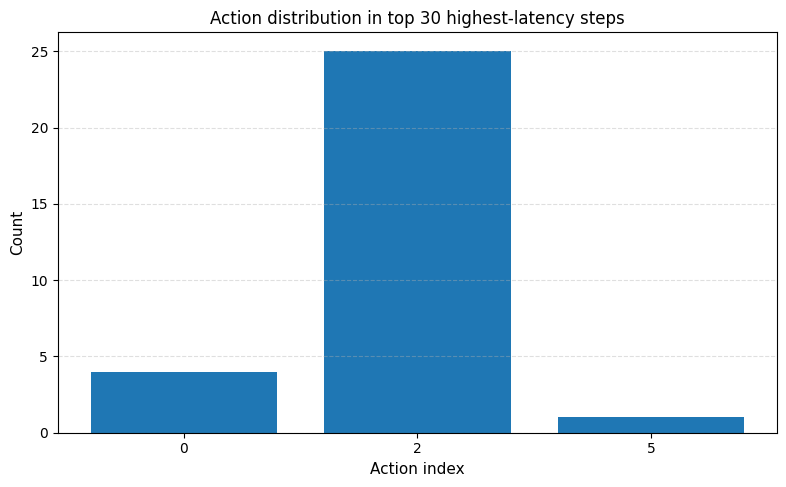

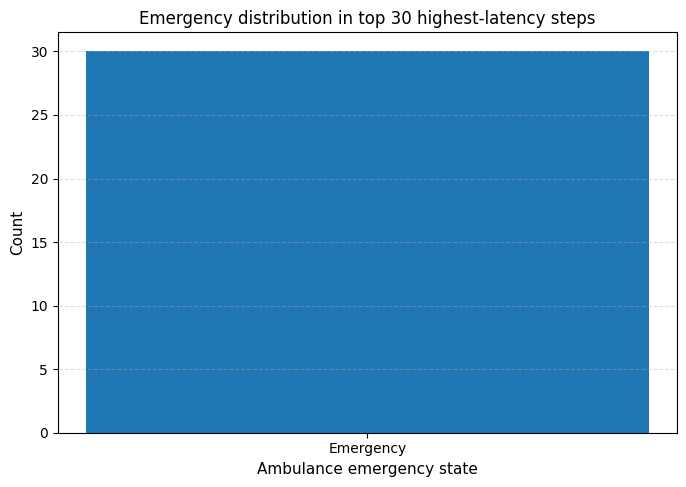

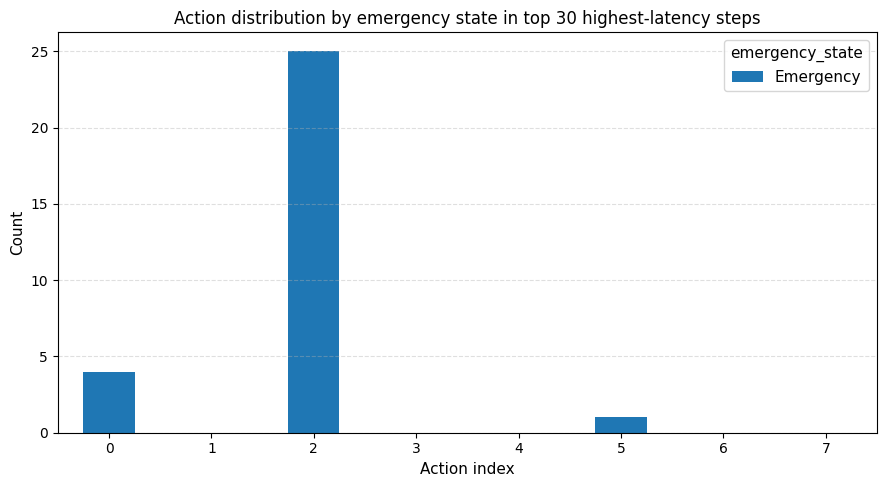


### Interpretation of top 30 highest-latency steps

- Mean alpha_A in worst-latency steps: **0.283**
- Emergency ratio in worst-latency steps: **100.00%**
- Low-alpha ratio (alpha_A <= 0.3): **13.33%**
- Emergency and low-alpha ratio: **13.33%**
- Mean ambulance arrival: **1.4373 Mbit**
- Mean ambulance capacity: **5.3039 Mbps**
- Mean ambulance latency: **0.3047 s**

Preliminary conclusion:

The highest-latency cases are mainly associated with ambulance arrival bursts. Since queue-before is low and capacity is not near zero, the latency outliers are likely caused by sudden arrivals within the current decision interval.


Saved figures:
D:\Projects\dqn-ran-slicing-oran-iov\results\diagnostics\worst_latency_action_distribution.png
D:\Projects\dqn-ran-slicing-oran-iov\results\diagnostics\worst_latency_emergency_distribution.png
D:\Projects\dqn-ran-slicing-oran-iov\results\diagnostics\worst_latency_action_by_emergency.png


In [ ]:

# ============================================================
# Analyze action and emergency distribution in worst-latency steps
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

# ------------------------------------------------------------
# 1. Ensure dataframe exists
# ------------------------------------------------------------
if "df" not in globals():
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

    RESULTS_DIR = PROJECT_ROOT / "results"

    debug_files = sorted(
        RESULTS_DIR.glob("dqn_300k_debug_steps_*.csv"),
        key=lambda p: p.stat().st_mtime
    )

    normal_files = sorted(
        RESULTS_DIR.glob("dqn_300k_steps_*.csv"),
        key=lambda p: p.stat().st_mtime
    )

    if debug_files:
        steps_path = debug_files[-1]
    elif normal_files:
        steps_path = normal_files[-1]
    else:
        raise FileNotFoundError("No DQN step-level CSV file found in results/.")

    print(f"Loading: {steps_path}")
    df = pd.read_csv(steps_path)

print("Data shape:", df.shape)
print("Available columns:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 2. Required columns check
# ------------------------------------------------------------
required_cols = [
    "episode",
    "step",
    "action",
    "alpha_A",
    "ambulance_emergency",
    "ambulance_arrival_mbit",
    "ambulance_capacity_mbps",
    "ambulance_latency_s",
    "reward_total",
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# ------------------------------------------------------------
# 3. Select top-N highest latency steps
# ------------------------------------------------------------
TOP_N = 30

worst = (
    df.sort_values("ambulance_latency_s", ascending=False)
      .head(TOP_N)
      .copy()
)

# Convert emergency column to bool if needed
if worst["ambulance_emergency"].dtype != bool:
    worst["ambulance_emergency"] = worst["ambulance_emergency"].astype(str).str.lower().isin(
        ["true", "1", "yes"]
    )

# Add readable labels
worst["latency_ms"] = worst["ambulance_latency_s"] * 1000.0
worst["ambulance_prb_ratio_percent"] = worst["alpha_A"] * 100.0
worst["emergency_state"] = np.where(
    worst["ambulance_emergency"],
    "Emergency",
    "Non-emergency"
)

# ------------------------------------------------------------
# 4. Print action distribution in worst 30
# ------------------------------------------------------------
print("=" * 80)
print(f"Action distribution in top {TOP_N} highest-latency steps")
print("=" * 80)

action_counts = (
    worst["action"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

action_counts["percentage"] = 100.0 * action_counts["count"] / TOP_N

# Add PRB ratio labels if alpha_A is available per action
action_alpha_map = (
    worst.groupby("action")["alpha_A"]
    .mean()
    .mul(100)
    .round(1)
)

action_counts["mean_alpha_A_percent"] = action_alpha_map

display(action_counts)

# ------------------------------------------------------------
# 5. Print emergency distribution in worst 30
# ------------------------------------------------------------
print("=" * 80)
print(f"Emergency distribution in top {TOP_N} highest-latency steps")
print("=" * 80)

emergency_counts = (
    worst["emergency_state"]
    .value_counts()
    .rename("count")
    .to_frame()
)

emergency_counts["percentage"] = 100.0 * emergency_counts["count"] / TOP_N

display(emergency_counts)

# ------------------------------------------------------------
# 6. Cross-tab: action vs emergency state
# ------------------------------------------------------------
print("=" * 80)
print(f"Action vs emergency state in top {TOP_N} highest-latency steps")
print("=" * 80)

action_emergency_table = pd.crosstab(
    worst["action"],
    worst["emergency_state"],
    margins=True
)

display(action_emergency_table)

action_emergency_percent = pd.crosstab(
    worst["action"],
    worst["emergency_state"],
    normalize="all"
) * 100.0

display(action_emergency_percent.round(2))

# ------------------------------------------------------------
# 7. Mean metrics by emergency state in worst 30
# ------------------------------------------------------------
print("=" * 80)
print(f"Mean metrics by emergency state in top {TOP_N} highest-latency steps")
print("=" * 80)

metric_cols = [
    "alpha_A",
    "ambulance_arrival_mbit",
    "ambulance_capacity_mbps",
    "ambulance_latency_s",
    "latency_ms",
    "reward_total",
]

optional_cols = [
    "n_ambulance",
    "ambulance_queue_before_mbit",
    "ambulance_queue_after_mbit",
    "latency_numerator_mbit",
    "latency_denominator_mbps",
]

metric_cols += [c for c in optional_cols if c in worst.columns]

mean_by_emergency = (
    worst.groupby("emergency_state")[metric_cols]
    .mean(numeric_only=True)
    .round(4)
)

display(mean_by_emergency)

# ------------------------------------------------------------
# 8. Mean metrics by action in worst 30
# ------------------------------------------------------------
print("=" * 80)
print(f"Mean metrics by action in top {TOP_N} highest-latency steps")
print("=" * 80)

mean_by_action = (
    worst.groupby("action")[metric_cols]
    .mean(numeric_only=True)
    .round(4)
)

count_by_action = worst.groupby("action").size().rename("count")
mean_by_action = mean_by_action.join(count_by_action)

display(mean_by_action)

# ------------------------------------------------------------
# 9. Inspect the actual worst rows
# ------------------------------------------------------------
print("=" * 80)
print(f"Top {TOP_N} highest-latency rows")
print("=" * 80)

display_cols = [
    "episode",
    "step",
    "action",
    "alpha_A",
    "ambulance_prb_ratio_percent",
    "n_ambulance",
    "ambulance_emergency",
    "ambulance_arrival_mbit",
    "ambulance_capacity_mbps",
    "ambulance_latency_s",
    "latency_ms",
    "reward_total",
]

debug_cols = [
    "ambulance_queue_before_mbit",
    "ambulance_queue_after_mbit",
    "latency_numerator_mbit",
    "latency_denominator_mbps",
    "reconstructed_latency_s",
]

display_cols += [c for c in debug_cols if c in worst.columns]
display_cols = [c for c in display_cols if c in worst.columns]

display(worst[display_cols])

# ------------------------------------------------------------
# 10. Plot action distribution in worst 30
# ------------------------------------------------------------
figures_dir = Path("results/diagnostics")
if not figures_dir.exists():
    PROJECT_ROOT = Path.cwd().resolve()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
    figures_dir = PROJECT_ROOT / "results" / "diagnostics"

figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.bar(action_counts.index.astype(str), action_counts["count"])
plt.xlabel("Action index")
plt.ylabel("Count")
plt.title(f"Action distribution in top {TOP_N} highest-latency steps")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

action_fig_path = figures_dir / "worst_latency_action_distribution.png"
plt.savefig(action_fig_path, dpi=300)
plt.show()

# ------------------------------------------------------------
# 11. Plot emergency distribution in worst 30
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.bar(emergency_counts.index, emergency_counts["count"])
plt.xlabel("Ambulance emergency state")
plt.ylabel("Count")
plt.title(f"Emergency distribution in top {TOP_N} highest-latency steps")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

emergency_fig_path = figures_dir / "worst_latency_emergency_distribution.png"
plt.savefig(emergency_fig_path, dpi=300)
plt.show()

# ------------------------------------------------------------
# 12. Plot action distribution by emergency state
# ------------------------------------------------------------
plot_table = pd.crosstab(worst["action"], worst["emergency_state"])

# Ensure all actions 0..7 appear
plot_table = plot_table.reindex(range(8), fill_value=0)

ax = plot_table.plot(kind="bar", figsize=(9, 5))
ax.set_xlabel("Action index")
ax.set_ylabel("Count")
ax.set_title(f"Action distribution by emergency state in top {TOP_N} highest-latency steps")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=0)
plt.tight_layout()

action_emergency_fig_path = figures_dir / "worst_latency_action_by_emergency.png"
plt.savefig(action_emergency_fig_path, dpi=300)
plt.show()

# ------------------------------------------------------------
# 13. Automatic interpretation
# ------------------------------------------------------------
high_latency_mean_alpha = worst["alpha_A"].mean()
emergency_ratio = worst["ambulance_emergency"].mean()
mean_arrival = worst["ambulance_arrival_mbit"].mean()
mean_capacity = worst["ambulance_capacity_mbps"].mean()
mean_latency = worst["ambulance_latency_s"].mean()

low_alpha_ratio = (worst["alpha_A"] <= 0.3).mean()
emergency_low_alpha_ratio = (
    (worst["ambulance_emergency"] == True) & (worst["alpha_A"] <= 0.3)
).mean()

summary_text = f"""
### Interpretation of top {TOP_N} highest-latency steps

- Mean alpha_A in worst-latency steps: **{high_latency_mean_alpha:.3f}**
- Emergency ratio in worst-latency steps: **{100 * emergency_ratio:.2f}%**
- Low-alpha ratio (alpha_A <= 0.3): **{100 * low_alpha_ratio:.2f}%**
- Emergency and low-alpha ratio: **{100 * emergency_low_alpha_ratio:.2f}%**
- Mean ambulance arrival: **{mean_arrival:.4f} Mbit**
- Mean ambulance capacity: **{mean_capacity:.4f} Mbps**
- Mean ambulance latency: **{mean_latency:.4f} s**

Preliminary conclusion:
"""

if emergency_low_alpha_ratio > 0.5:
    summary_text += """
The highest-latency cases are strongly associated with emergency states where the DQN selected a low PRB ratio for the Ambulance Slice. This suggests that the learned policy may not react aggressively enough to emergency traffic bursts.
"""
elif low_alpha_ratio > 0.5:
    summary_text += """
The highest-latency cases are strongly associated with low PRB allocation to the Ambulance Slice. This suggests that insufficient PRB allocation is an important contributor to latency outliers.
"""
elif mean_arrival > mean_capacity * 0.1:
    summary_text += """
The highest-latency cases are mainly associated with ambulance arrival bursts. Since queue-before is low and capacity is not near zero, the latency outliers are likely caused by sudden arrivals within the current decision interval.
"""
else:
    summary_text += """
The highest-latency cases do not appear to be explained by a single dominant factor. They may result from mixed causes involving traffic bursts, action selection, and stochastic channel conditions.
"""

display(Markdown(summary_text))

print("Saved figures:")
print(action_fig_path)
print(emergency_fig_path)
print(action_emergency_fig_path)



In [ ]:
# ============================================================
# Re-check alpha distribution with floating-point tolerance
# ============================================================

TOP_N = 30
worst = df.sort_values("ambulance_latency_s", ascending=False).head(TOP_N).copy()

print("Raw alpha_A unique values in worst 30:")
print(sorted(worst["alpha_A"].unique()))

print("\nAlpha_A value counts:")
print(worst["alpha_A"].value_counts().sort_index())

print("\nAction value counts:")
print(worst["action"].value_counts().sort_index())

# Use tolerance for floating-point comparison
tol = 1e-6
worst["low_alpha_strict"] = worst["alpha_A"] <= 0.3
worst["low_alpha_tol"] = worst["alpha_A"] <= (0.3 + tol)

print("\nLow alpha ratio without tolerance:")
print(worst["low_alpha_strict"].mean() * 100)

print("\nLow alpha ratio with tolerance:")
print(worst["low_alpha_tol"].mean() * 100)

print("\nMean alpha_A:")
print(worst["alpha_A"].mean())

display(worst[[
    "episode",
    "step",
    "action",
    "alpha_A",
    "low_alpha_strict",
    "low_alpha_tol",
    "ambulance_emergency",
    "ambulance_arrival_mbit",
    "ambulance_capacity_mbps",
    "ambulance_latency_s",
    "reward_total"
]])

Raw alpha_A unique values in worst 30:
[np.float64(0.1000000014901161), np.float64(0.3000000119209289), np.float64(0.6000000238418579)]

Alpha_A value counts:
alpha_A
0.1     4
0.3    25
0.6     1
Name: count, dtype: int64

Action value counts:
action
0     4
2    25
5     1
Name: count, dtype: int64

Low alpha ratio without tolerance:
13.333333333333334

Low alpha ratio with tolerance:
96.66666666666667

Mean alpha_A:
0.2833333442608515


,episode,step,action,alpha_A,low_alpha_strict,low_alpha_tol,ambulance_emergency,ambulance_arrival_mbit,ambulance_capacity_mbps,ambulance_latency_s,reward_total
278,1,78,0,0.1,True,True,True,1.42,1.691617,0.839433,-31.497994
597,2,197,0,0.1,True,True,True,1.50,2.140813,0.700668,-27.472538
5616,28,16,0,0.1,True,True,True,1.55,2.750688,0.563495,-23.357356
5661,28,61,0,0.1,True,True,True,1.06,2.423702,0.437347,-19.365417
1855,9,55,2,0.3,False,True,True,1.52,3.894933,0.390251,-17.732517
3755,18,155,2,0.3,False,True,True,1.50,4.323300,0.346957,-16.408712
3728,18,128,2,0.3,False,True,True,1.61,5.663419,0.284281,-14.528416
5348,26,148,2,0.3,False,True,True,1.59,5.694161,0.279233,-14.377001
2142,10,142,2,0.3,False,True,True,1.43,5.199868,0.275007,-14.710208
2879,14,79,2,0.3,False,True,True,1.69,6.166831,0.274047,-14.221402


In [ ]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"

files = sorted(
    RESULTS_DIR.glob("dqn_300k_emergency_obs_steps_*.csv"),
    key=lambda p: p.stat().st_mtime
)

steps_path = files[-1]
print("Using:", steps_path)

df = pd.read_csv(steps_path)

worst = df.sort_values("ambulance_latency_s", ascending=False).head(30).copy()

print("Emergency ratio in worst 30:")
print(worst["ambulance_emergency"].mean())

print("\nAction distribution in worst 30:")
print(worst["action"].value_counts().sort_index())

print("\nAlpha distribution in worst 30:")
print(worst["alpha_A"].round(1).value_counts().sort_index())

print("\nWorst 30 mean values:")
print(worst[[
    "ambulance_arrival_mbit",
    "ambulance_queue_before_mbit",
    "latency_numerator_mbit",
    "ambulance_capacity_mbps",
    "latency_denominator_mbps",
    "ambulance_latency_s",
    "alpha_A",
    "reward_total"
]].mean(numeric_only=True))

In [ ]:
condition_percent = root_cause_table.set_index("condition")["percent_in_top_30_latency"].to_dict()

if strict_inconsistency_reasons:
    best_cause = "logging/model inconsistency"
else:
    candidate_scores = {
        "high latency numerator": condition_percent.get("high_latency_numerator_mbit", 0.0),
        "low latency denominator / capacity bottleneck": condition_percent.get("low_latency_denominator_mbps", 0.0),
        "high queue before latency computation": condition_percent.get("high_queue_before_mbit", 0.0),
        "traffic burst": condition_percent.get("high_arrival", 0.0),
        "low PRB allocation during emergency": condition_percent.get("emergency_and_low_alpha", 0.0),
    }
    best_cause = max(candidate_scores, key=candidate_scores.get)
    if candidate_scores[best_cause] < 50.0:
        best_cause = "mixed causes"

conclusion = f"""
### Root-cause conclusion

The most likely root cause category from the logged fields is **{best_cause}**.

For the top 30 highest-latency steps:
- High latency numerator: {condition_percent.get('high_latency_numerator_mbit', 0.0):.1f}%
- Low latency denominator / capacity: {condition_percent.get('low_latency_denominator_mbps', 0.0):.1f}%
- High queue before latency computation: {condition_percent.get('high_queue_before_mbit', 0.0):.1f}%
- High ambulance arrival: {condition_percent.get('high_arrival', 0.0):.1f}%
- Emergency and low alpha_A: {condition_percent.get('emergency_and_low_alpha', 0.0):.1f}%

Strict logging/model inconsistency reasons: {strict_inconsistency_reasons if strict_inconsistency_reasons else 'none'}.

If `max latency_error < 1e-6`, the logged numerator and denominator reconstruct `ambulance_latency_s`, so the high latency is not classified as a logging/model inconsistency from the latency formula itself.
"""
display(Markdown(conclusion))


### Root-cause conclusion

The most likely root cause category from the logged fields is **mixed causes**.

For the top 30 highest-latency steps:
- High latency numerator: 46.7%
- Low latency denominator / capacity: 0.0%
- High queue before latency computation: 0.0%
- High ambulance arrival: 46.7%
- Emergency and low alpha_A: 13.3%

Strict logging/model inconsistency reasons: none.

If `max latency_error < 1e-6`, the logged numerator and denominator reconstruct `ambulance_latency_s`, so the high latency is not classified as a logging/model inconsistency from the latency formula itself.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"

files = sorted(
    RESULTS_DIR.glob("dqn_300k_obs_debug_steps_*.csv"),
    key=lambda p: p.stat().st_mtime
)

steps_path = files[-1]
print("Using:", steps_path)

df = pd.read_csv(steps_path)

worst = df.sort_values("ambulance_latency_s", ascending=False).head(30).copy()

cols = [
    "episode", "step",
    "selected_action", "selected_alpha_A",
    "alpha_A",
    "ambulance_emergency",
    "n_ambulance",
    "ambulance_arrival_mbit",
    "ambulance_capacity_mbps",
    "ambulance_latency_s",
    "reward_total",
    "obs_n_A",
    "obs_rho_A",
    "obs_q_A",
    "obs_l_A",
    "obs_r_O",
    "obs_alpha_A_prev",
]

display(worst[[c for c in cols if c in worst.columns]])

print("Mean observation values in worst 30:")
display(worst[[c for c in cols if c.startswith("obs_") and c in worst.columns]].mean())

print("Action distribution in worst 30:")
display(worst["selected_action"].value_counts().sort_index())

print("Alpha distribution in worst 30:")
display(worst["selected_alpha_A"].value_counts().sort_index())

print("Emergency ratio in worst 30:")
print(worst["ambulance_emergency"].mean())

Using: D:\Projects\dqn-ran-slicing-oran-iov\results\dqn_300k_obs_debug_steps_20260609_155825.csv


,episode,step,selected_action,selected_alpha_A,alpha_A,ambulance_emergency,n_ambulance,ambulance_arrival_mbit,ambulance_capacity_mbps,ambulance_latency_s,reward_total,obs_n_A,obs_rho_A,obs_q_A,obs_l_A,obs_r_O,obs_alpha_A_prev
278,1,78,0,0.1,0.1,True,3,1.42,1.691617,0.839433,-31.497994,0.333333,0.020000,0.0,0.078288,0.6825,0.1
597,2,197,0,0.1,0.1,True,3,1.50,2.140813,0.700668,-27.472538,0.333333,0.013333,0.0,0.068446,0.5000,0.1
5616,28,16,0,0.1,0.1,True,3,1.55,2.750688,0.563495,-23.357356,0.000000,0.000000,0.0,0.000000,0.6875,0.3
5661,28,61,0,0.1,0.1,True,2,1.06,2.423702,0.437347,-19.365417,0.000000,0.000000,0.0,0.000000,0.6175,0.3
1855,9,55,2,0.3,0.3,True,3,1.52,3.894933,0.390251,-17.732517,0.000000,0.000000,0.0,0.000000,0.9950,0.3
3755,18,155,2,0.3,0.3,True,3,1.50,4.323300,0.346957,-16.408712,0.000000,0.000000,0.0,0.000000,1.0000,0.3
3728,18,128,2,0.3,0.3,True,3,1.61,5.663419,0.284281,-14.528416,0.333333,0.046667,0.0,0.088472,1.0000,0.3
5348,26,148,2,0.3,0.3,True,3,1.59,5.694161,0.279233,-14.377001,0.333333,0.053333,0.0,0.069059,1.0000,0.3
2142,10,142,2,0.3,0.3,True,3,1.43,5.199868,0.275007,-14.710208,0.000000,0.000000,0.0,0.000000,0.7800,0.1
2879,14,79,2,0.3,0.3,True,3,1.69,6.166831,0.274047,-14.221402,0.333333,0.020000,0.0,0.058992,1.0000,0.3


Mean observation values in worst 30:


obs_n_A             0.155556
obs_rho_A           0.032889
obs_q_A             0.000000
obs_l_A             0.059987
obs_r_O             0.925667
obs_alpha_A_prev    0.290000
dtype: float64

Action distribution in worst 30:


selected_action
0     4
2    25
5     1
Name: count, dtype: int64

Alpha distribution in worst 30:


selected_alpha_A
0.1     4
0.3    25
0.6     1
Name: count, dtype: int64

Emergency ratio in worst 30:
1.0


In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"

files = sorted(
    RESULTS_DIR.glob("dqn_300k_emergency_obs_steps_*.csv"),
    key=lambda p: p.stat().st_mtime
)

steps_path = files[-1]
print("Using:", steps_path)

df = pd.read_csv(steps_path)

worst = df.sort_values("ambulance_latency_s", ascending=False).head(30).copy()

print("Emergency ratio in worst 30:")
print(worst["ambulance_emergency"].mean())

print("\nAction distribution in worst 30:")
print(worst["action"].value_counts().sort_index())

print("\nAlpha distribution in worst 30:")
print(worst["alpha_A"].round(1).value_counts().sort_index())

print("\nWorst 30 mean values:")
print(worst[[
    "ambulance_arrival_mbit",
    "ambulance_queue_before_mbit",
    "latency_numerator_mbit",
    "ambulance_capacity_mbps",
    "latency_denominator_mbps",
    "ambulance_latency_s",
    "alpha_A",
    "reward_total"
]].mean(numeric_only=True))

Using: D:\Projects\dqn-ran-slicing-oran-iov\results\dqn_300k_emergency_obs_steps_20260610_012237.csv
Emergency ratio in worst 30:
1.0

Action distribution in worst 30:
action
0    30
Name: count, dtype: int64

Alpha distribution in worst 30:
alpha_A
0.1    30
Name: count, dtype: int64

Worst 30 mean values:
ambulance_arrival_mbit          1.409333
ambulance_queue_before_mbit     0.000000
latency_numerator_mbit          1.409333
ambulance_capacity_mbps         2.271290
latency_denominator_mbps        2.271291
ambulance_latency_s             0.632561
alpha_A                         0.100000
reward_total                  -25.057824
dtype: float64
